In [34]:
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from PIL import Image
import pandas as pd
import numpy as np
import base64

In [35]:
root_path = "/home/stefan/ioai-prep/kits/the-defected-nuts-aicc-round-1/data"

# Data

In [36]:
train_dir = Path(f"{root_path}/train")
train_paths = sorted(train_dir.glob("*.png"), key=lambda x: int(x.stem))
train_images = np.array([np.array(Image.open(p)) for p in train_paths])

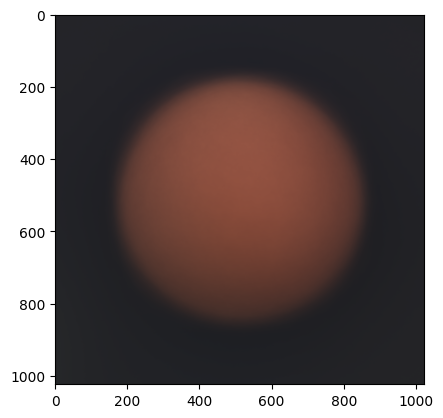

In [37]:
mean_image = train_images.mean(axis=0)
plt.imshow(mean_image / 255)

# Processing

In [38]:
test_dir = Path(f"{root_path}/test")
test_paths = sorted(test_dir.glob("*.png"), key=lambda x: int(x.stem))
test_images = [np.array(Image.open(p)) for p in test_paths]

In [39]:
anomaly_maps = []

for i, test_img in enumerate(tqdm(test_images)):
    # Compute absolute difference from mean
    diff = np.abs(test_img.astype(float) - mean_image)

    # Average across channels
    anomaly_score = diff.mean(axis=-1)

    # Normalize to [0, 255]
    anomaly_score = (anomaly_score / anomaly_score.max() * 255).astype(np.uint8)
    anomaly_maps.append(anomaly_score)

anomaly_maps = np.array(anomaly_maps)

100%|██████████| 70/70 [00:01<00:00, 42.90it/s]


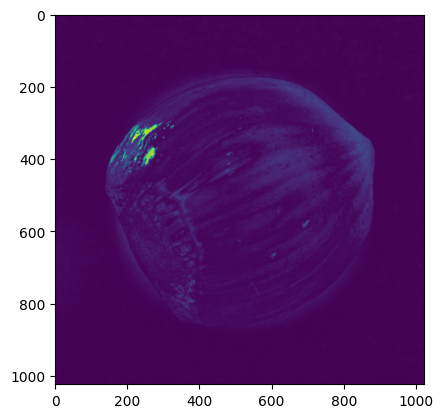

In [40]:
plt.imshow(anomaly_maps[0])

# Submission

In [41]:
submission = pd.DataFrame(columns=["data"])

for i, anomaly_map in enumerate(tqdm(anomaly_maps)):
    submission.loc[i] = base64.b85encode(anomaly_map.tobytes()).decode("ascii")

submission = submission.reset_index()
submission.columns = ["id", "data"]
submission.head()

100%|██████████| 70/70 [00:05<00:00, 12.38it/s]


,id,data
0,0,0RaI60ssL40RaI40s{d80s{j90ssI30RaI40RRC200II50...
1,1,2?+)W1_uQO1_S~I2L=iU1PBQW3I+rN3ke1Y1qKKS3I_!R1...
2,2,2?+@a2MG)a2@D7b3kwVn3kC=W3JDGm5*ZsB8XX@U9~~eb9...
3,3,3kwSk4-F0j3K9(s3kwMi4GRVZ2L=ZW4+#nl4G<0x6%!B+4...
4,4,2L=WT2L%NQ3I_=a3I_uQ2mu5G0t5&I1P2KS1qB5L2L%NJ1...


In [42]:
submission.to_csv(f"{root_path}/submission.csv", index=False)